# ChinaPV Expansion Dataset (2010 - 2022)

The **ChinaPV Expansion Dataset** (Chen et al., 2024) provides insights into the spatial distribution and rapid growth of solar photovoltaic (PV) power plants across China from 2010 to 2022.

- Developed using **Sentinel-2 and Landsat** imagery.
- PV detection was performed using a **deep learning model (TransUNet)** trained on satellite imagery and validated against ground truth data.
- The methodology includes:
  - **Image preprocessing** to enhance PV signal,
  - **Deep learning classification** to detect PV installations,
  - **Change detection (CCDC)** to estimate installation dates,
  - **Validation** against known PV plant locations.
- Output includes:
  - Geospatial locations of PV power plants,
  - Installation dates from 2010–2022,
  - Insights on spatial distribution and growth trends.

- Key Findings:
  - **Rapid expansion** of PV power plants across China, with total area growing from 5.86 km² (2010) to 3712.1 km² (2022),
  - Western China: larger PV areas but fewer large plants,
  - Eastern/Central China: smaller PV areas but more numerous small plants,
  - Identification of land use impacts: cropland in east/central, grassland and unused land in west.

This study and dataset are described in the following paper:  
> **Chen, Y., Zhou, J., Ge, Y., Dong, J. (2024)**  
> *Uncovering the rapid expansion of photovoltaic power plants in China from 2010 to 2022 using satellite data and deep learning*  
> *Remote Sensing of Environment*, **312**, 114100  
> [https://doi.org/10.1016/j.rse.2024.114100](https://doi.org/10.1016/j.rse.2024.114100)

The dataset is publicly available on **figshare**: 
> [ChinaPV Expansion Dataset](https://figshare.com/articles/dataset/PV_power_plants_of_China_from_2010_to_2022/25347880/1?file=44877622)


## Setup

In [77]:
import os
import zipfile
import requests
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import seaborn as sns

## Download

In [3]:
# URL of the dataset
url = "https://figshare.com/ndownloader/files/44877622"

# Output folder
output_folder = os.path.join("..", "..", "data", "raw_data", "chinapv_expansion")
os.makedirs(output_folder, exist_ok=True)

# Download the file
print("Downloading dataset...")
response = requests.get(url)
zip_path = os.path.join(output_folder, "chinapv_expansion.zip")
with open(zip_path, "wb") as f:
    f.write(response.content)
print("✅ Downloaded")

# Extract files
print("Extracting files...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(output_folder)
os.remove(zip_path)
print(f"Deleted zip file: {zip_path}")

# List extracted files
print("Extracted files:", os.listdir(output_folder))

✅ Downloaded
Extracting files...
Deleted zip file: ..\..\data\raw_data\chinapv_expansion\chinapv_expansion.zip
Extracted files: ['PV power plants of China from 2010 to 2022']


## Clean

In [4]:
chinapv_expansion = gpd.read_file(r"C:\Users\charl\solar-data-china\data\raw_data\chinapv_expansion\PV power plants of China from 2010 to 2022\PV power plants of China from 2010 to 2022.shp")

In [5]:
print(chinapv_expansion.head())
chinapv_expansion.info()

   OBJECTID   PV_Area   Inst_time  Inst_year Major_type        Lat  \
0         0  0.041406  20220519.0       2022   Cropland  23.329377   
1         1  0.027605  20220811.0       2022   Cropland  23.326059   
2         2  0.062481  20220715.0       2022   Woodland  23.316059   
3         3  0.120969  20161028.0       2016  Grassland  22.814661   
4         4  0.067778  20190715.0       2019   Cropland  22.768299   

          Lon                                           geometry  
0  111.400431  POLYGON ((111.4 23.33, 111.4 23.33, 111.4 23.3...  
1  111.407242  POLYGON ((111.41 23.328, 111.41 23.328, 111.41...  
2  111.423811  POLYGON ((111.42 23.317, 111.42 23.317, 111.42...  
3  111.550705  POLYGON ((111.55 22.817, 111.55 22.817, 111.55...  
4  111.518755  POLYGON ((111.52 22.771, 111.52 22.771, 111.52...  
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 30023 entries, 0 to 30022
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --

In [6]:
chinapv_expansion['geometry'].nunique()

29979

In [7]:
# Drop 'OBJECTID' from comparison
duplicates_all = chinapv_expansion[
    chinapv_expansion.duplicated(subset=[col for col in chinapv_expansion.columns if col != "OBJECTID"], keep=False)
]

print("Duplicate rows (ignoring OBJECTID):")
print(duplicates_all)

Duplicate rows (ignoring OBJECTID):
       OBJECTID   PV_Area   Inst_time  Inst_year     Major_type        Lat  \
354         354  0.332293  20120622.0       2012      Grassland  43.406799   
355         355  0.332293  20120622.0       2012      Grassland  43.406799   
9281       9281  0.016720  20140424.0       2014       Cropland  33.486462   
9287       9287  0.016720  20140424.0       2014       Cropland  33.486462   
9293       9293  0.016720  20140424.0       2014       Cropland  33.486462   
...         ...       ...         ...        ...            ...        ...   
27159     27159  0.030830  20170707.0       2017  Built-up land  40.773551   
27160     27160  0.028107  20180604.0       2018  Built-up land  40.772528   
27161     27161  0.035143  20170529.0       2017  Built-up land  40.773240   
27288     27288  0.180983  20180627.0       2018       Cropland  34.564431   
27291     27291  0.180983  20180627.0       2018       Cropland  34.564431   

              Lon          

In [8]:
# Drop duplicates across all columns except OBJECTID
chinapv_expansion_clean = chinapv_expansion.drop_duplicates(
    subset=[col for col in chinapv_expansion.columns if col != "OBJECTID"],
    keep="first"  # keep first occurrence, drop the rest
).reset_index(drop=True)

# Drop a single column
chinapv_expansion_clean = chinapv_expansion_clean.drop(columns=["OBJECTID"])


print(f"Original rows: {len(chinapv_expansion)}")
print(f"Cleaned rows: {len(chinapv_expansion_clean)}")
print(chinapv_expansion_clean)


Original rows: 30023
Cleaned rows: 29979
        PV_Area   Inst_time  Inst_year     Major_type        Lat         Lon  \
0      0.041406  20220519.0       2022       Cropland  23.329377  111.400431   
1      0.027605  20220811.0       2022       Cropland  23.326059  111.407242   
2      0.062481  20220715.0       2022       Woodland  23.316059  111.423811   
3      0.120969  20161028.0       2016      Grassland  22.814661  111.550705   
4      0.067778  20190715.0       2019       Cropland  22.768299  111.518755   
...         ...         ...        ...            ...        ...         ...   
29974  0.004178  20220723.0       2022  Water surface  31.476444  119.644411   
29975  0.010110  20220723.0       2022  Water surface  31.477036  119.642590   
29976  0.024889  20220723.0       2022  Water surface  31.475981  119.653187   
29977  0.009210  20220723.0       2022  Water surface  31.476395  119.650808   
29978  0.013867  20220723.0       2022  Water surface  31.477532  119.647189   

### Installation Year Overview

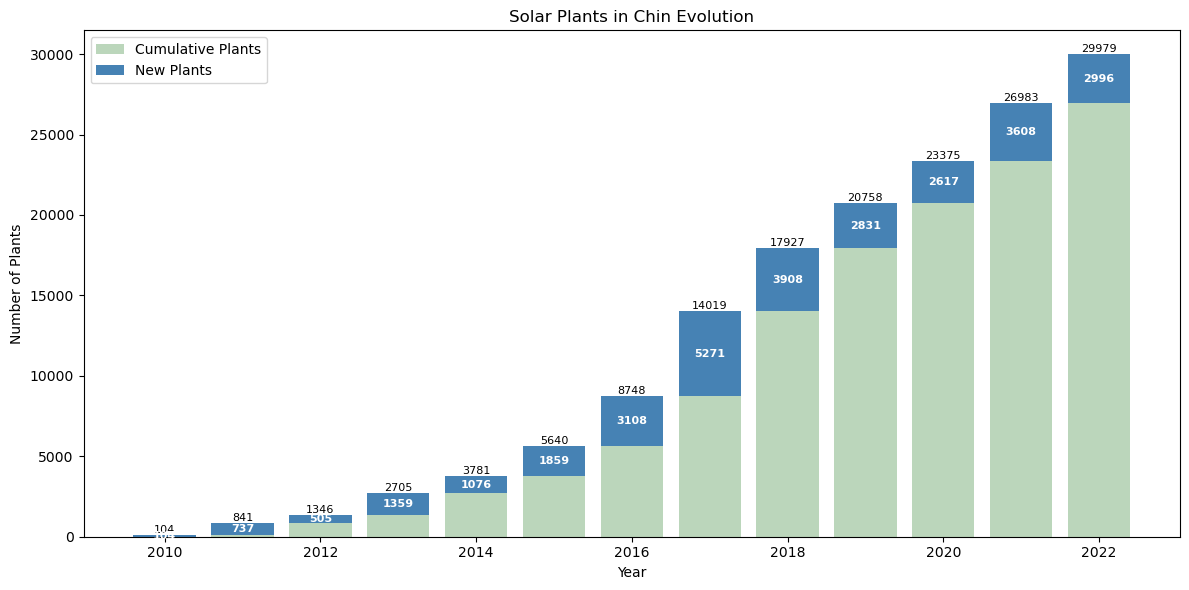

In [ ]:
# Count new plants per year
new_per_year = chinapv_expansion_clean.groupby("Inst_year").size()

# Cumulative sum (plants up to that year)
cumulative_per_year = new_per_year.cumsum()


plt.figure(figsize=(12, 6))

plt.bar(cumulative_per_year.index, cumulative_per_year.values, 
        color="darkseagreen", alpha=0.6, label="Cumulative Plants")

# Plot new per year stacked on top
plt.bar(new_per_year.index, new_per_year.values, 
        bottom=cumulative_per_year.shift(fill_value=0), 
        color="steelblue", label="New Plants")

# Titles and labels
plt.title("Solar Plants in China Evolution")
plt.xlabel("Year")
plt.ylabel("Number of Plants")

# Add legend
plt.legend()


# Annotate exact numbers
for x, y in zip(cumulative_per_year.index, cumulative_per_year.values):
    plt.text(x, y, str(y), ha='center', va='bottom', fontsize=8, color="black")

for x, y in zip(new_per_year.index, new_per_year.values):
    plt.text(x, cumulative_per_year.shift(fill_value=0)[x] + y/2,  # put inside the blue bar
             str(y), ha='center', va='center', fontsize=8, color="white", fontweight="bold")

plt.tight_layout()
plt.show()

In [11]:
# Expand df_agg so that each plant is repeated for all years >= its start year
years = sorted(chinapv_expansion["Inst_year"].unique())

expanded = []
for year in years:
    subset = chinapv_expansion[chinapv_expansion["Inst_year"] <= year].copy()
    subset["FrameYear"] = year
    expanded.append(subset)

df_expanded = pd.concat(expanded)

print(df_expanded.head())


      OBJECTID   PV_Area   Inst_time  Inst_year     Major_type        Lat  \
479        479  0.221993  20101204.0       2010      Grassland  30.093949   
568        568  0.218953  20100530.0       2010  Built-up land  40.072736   
570        570  0.300069  20100527.0       2010    Unused land  40.068777   
1760      1760  0.125685  20101004.0       2010      Grassland  40.762156   
2067      2067  0.071329  20100823.0       2010       Cropland  41.386823   

             Lon                                           geometry  FrameYear  
479    90.524309  POLYGON ((90.527 30.096, 90.527 30.096, 90.527...       2010  
568    94.525215  POLYGON ((94.53 40.075, 94.53 40.075, 94.53 40...       2010  
570    94.516268  POLYGON ((94.52 40.071, 94.52 40.071, 94.52 40...       2010  
1760  111.455788  POLYGON ((111.46 40.763, 111.46 40.763, 111.46...       2010  
2067  114.651454  POLYGON ((114.65 41.388, 114.65 41.388, 114.65...       2010  


In [20]:
fig = px.scatter_mapbox(
    df_expanded,
    lat="Lat",
    lon="Lon",
    animation_frame="FrameYear",
    mapbox_style="carto-positron",
    zoom=3,
    height=700,
    width=1000,
    title=f"Solar PV Plants in China Over Time"
)

fig.show()

## Focus village 

In [27]:
village_geom = gpd.read_file("../satellite_image/villages_geom.geojson")
village_geom.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [29]:
village_geom.head()

,Province,Province_pinyin,Province code,City,City_pinyin,City code,County,County_pinyin,County code,Township,Township_pinyin,Village,Village_pinyin,geometry
0,河北,Hebei,13,邯郸市,Handan,1304,大名县,Daming xian,130425,北峰乡,bei feng xiang,东夹河村委会,dong jia he cun wei hui,"POLYGON ((115.43 36.208, 115.43 36.203, 115.41..."
1,河北,Hebei,13,邯郸市,Handan,1304,大名县,Daming xian,130425,埝头乡,nian tou xiang,朱村村村委会,zhu cun cun cun wei hui,"POLYGON ((115.41 36.137, 115.41 36.138, 115.4 ..."
2,河北,Hebei,13,邯郸市,Handan,1304,大名县,Daming xian,130425,大名镇,da ming zhen,吴水坑村委会,wu shui keng cun wei hui,"POLYGON ((115.15 36.265, 115.14 36.265, 115.14..."
3,河北,Hebei,13,邯郸市,Handan,1304,大名县,Daming xian,130425,大街乡,da jie xiang,张郭村委会,zhang guo cun wei hui,"POLYGON ((115.19 36.311, 115.19 36.313, 115.19..."
4,河北,Hebei,13,邯郸市,Handan,1304,大名县,Daming xian,130425,张铁集乡,zhang tie ji xiang,北刘店村委会,bei liu dian cun wei hui,"POLYGON ((115.4 36.262, 115.39 36.259, 115.39 ..."


In [24]:
chinapv_expansion_clean.to_crs(village_geom.crs)

,PV_Area,Inst_time,Inst_year,Major_type,Lat,Lon,geometry
0,0.041406,20220519.0,2022,Cropland,23.329377,111.400431,"POLYGON ((111.4 23.33, 111.4 23.33, 111.4 23.3..."
1,0.027605,20220811.0,2022,Cropland,23.326059,111.407242,"POLYGON ((111.41 23.328, 111.41 23.328, 111.41..."
2,0.062481,20220715.0,2022,Woodland,23.316059,111.423811,"POLYGON ((111.42 23.317, 111.42 23.317, 111.42..."
3,0.120969,20161028.0,2016,Grassland,22.814661,111.550705,"POLYGON ((111.55 22.817, 111.55 22.817, 111.55..."
4,0.067778,20190715.0,2019,Cropland,22.768299,111.518755,"POLYGON ((111.52 22.771, 111.52 22.771, 111.52..."
...,...,...,...,...,...,...,...
29974,0.004178,20220723.0,2022,Water surface,31.476444,119.644411,"POLYGON ((119.64 31.477, 119.64 31.477, 119.64..."
29975,0.010110,20220723.0,2022,Water surface,31.477036,119.642590,"POLYGON ((119.64 31.478, 119.64 31.478, 119.64..."
29976,0.024889,20220723.0,2022,Water surface,31.475981,119.653187,"POLYGON ((119.65 31.477, 119.65 31.477, 119.65..."
29977,0.009210,20220723.0,2022,Water surface,31.476395,119.650808,"POLYGON ((119.65 31.477, 119.65 31.477, 119.65..."


In [82]:
joined = gpd.sjoin(chinapv_expansion_clean, village_geom.drop(columns = ["Village", "Village_pinyin"]))

joined

,PV_Area,Inst_time,Inst_year,Major_type,Lat,Lon,geometry,index_right,Province,Province_pinyin,Province code,City,City_pinyin,City code,County,County_pinyin,County code,Township,Township_pinyin
1563,0.001977,20181024.0,2018,Woodland,40.423886,114.780896,"POLYGON ((114.78 40.424, 114.78 40.424, 114.78...",15,河北,Hebei,13,张家口市,Zhangjiakou,1307,宣化县,Xuanhua xian,130721,深井镇,shen jing zhen
1564,0.000760,20221120.0,2022,Grassland,40.423604,114.810802,"POLYGON ((114.81 40.424, 114.81 40.424, 114.81...",15,河北,Hebei,13,张家口市,Zhangjiakou,1307,宣化县,Xuanhua xian,130721,深井镇,shen jing zhen
1565,0.044678,20171010.0,2017,Grassland,40.424230,114.807840,"POLYGON ((114.81 40.425, 114.81 40.425, 114.81...",15,河北,Hebei,13,张家口市,Zhangjiakou,1307,宣化县,Xuanhua xian,130721,深井镇,shen jing zhen
1566,0.008669,20141024.0,2014,Grassland,40.423898,114.897183,"POLYGON ((114.9 40.424, 114.9 40.424, 114.9 40...",15,河北,Hebei,13,张家口市,Zhangjiakou,1307,宣化县,Xuanhua xian,130721,深井镇,shen jing zhen
1567,0.017833,20161109.0,2016,Grassland,40.423505,114.787079,"POLYGON ((114.79 40.425, 114.79 40.424, 114.79...",15,河北,Hebei,13,张家口市,Zhangjiakou,1307,宣化县,Xuanhua xian,130721,深井镇,shen jing zhen
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28859,0.049849,20200625.0,2020,Grassland,40.433268,114.802850,"POLYGON ((114.8 40.434, 114.8 40.434, 114.8 40...",15,河北,Hebei,13,张家口市,Zhangjiakou,1307,宣化县,Xuanhua xian,130721,深井镇,shen jing zhen
28860,0.014665,20170709.0,2017,Grassland,40.431681,114.800950,"POLYGON ((114.8 40.432, 114.8 40.432, 114.8 40...",15,河北,Hebei,13,张家口市,Zhangjiakou,1307,宣化县,Xuanhua xian,130721,深井镇,shen jing zhen
28861,0.047929,20170903.0,2017,Grassland,40.429816,114.799974,"POLYGON ((114.8 40.431, 114.8 40.431, 114.8 40...",15,河北,Hebei,13,张家口市,Zhangjiakou,1307,宣化县,Xuanhua xian,130721,深井镇,shen jing zhen
28960,0.002133,20210423.0,2021,Grassland,40.319316,114.830115,"POLYGON ((114.83 40.32, 114.83 40.319, 114.83 ...",16,河北,Hebei,13,张家口市,Zhangjiakou,1307,宣化县,Xuanhua xian,130721,王家湾乡,wang jia wan xiang


In [83]:
if "index_right" in joined.columns:
    joined = joined.drop(columns=["index_right"])

joined.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 316 entries, 1563 to 29917
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   PV_Area          316 non-null    float64 
 1   Inst_time        316 non-null    float64 
 2   Inst_year        316 non-null    int32   
 3   Major_type       316 non-null    object  
 4   Lat              316 non-null    float64 
 5   Lon              316 non-null    float64 
 6   geometry         316 non-null    geometry
 7   Province         316 non-null    object  
 8   Province_pinyin  316 non-null    object  
 9   Province code    316 non-null    int32   
 10  City             316 non-null    object  
 11  City_pinyin      316 non-null    object  
 12  City code        316 non-null    int32   
 13  County           316 non-null    object  
 14  County_pinyin    316 non-null    object  
 15  County code      316 non-null    int32   
 16  Township         316 non-null    obj

## Exploratory 

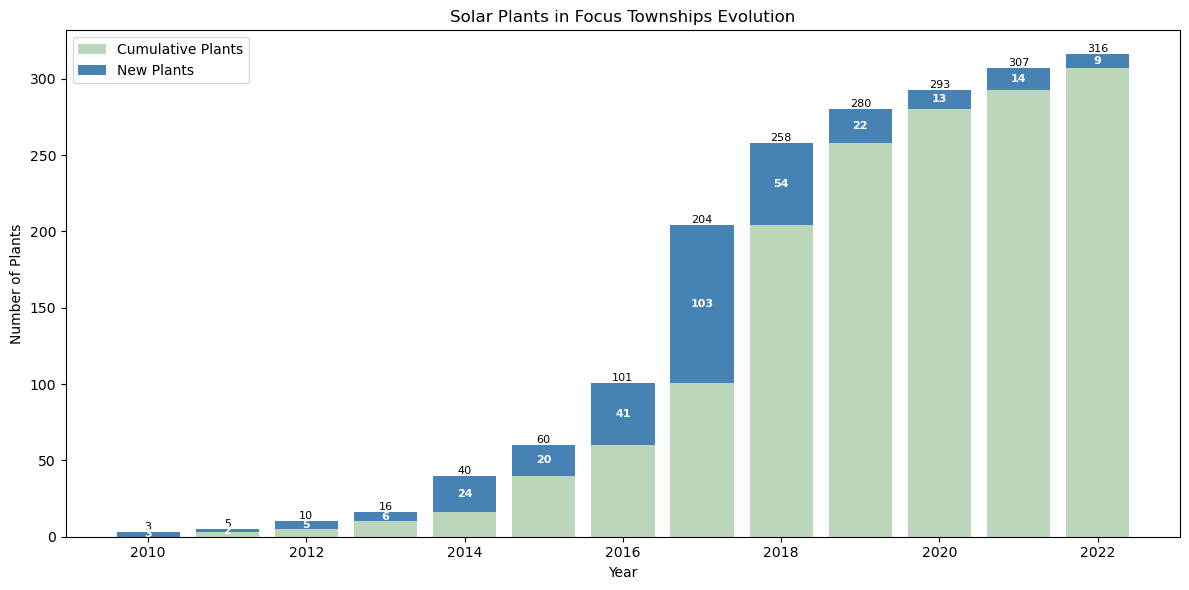

In [85]:
# Count new plants per year
new_per_year = joined.groupby("Inst_year").size()

# Cumulative sum (plants up to that year)
cumulative_per_year = new_per_year.cumsum()


plt.figure(figsize=(12, 6))

plt.bar(cumulative_per_year.index, cumulative_per_year.values, 
        color="darkseagreen", alpha=0.6, label="Cumulative Plants")

# Plot new per year stacked on top
plt.bar(new_per_year.index, new_per_year.values, 
        bottom=cumulative_per_year.shift(fill_value=0), 
        color="steelblue", label="New Plants")

# Titles and labels
plt.title("Solar Plants in Focus Townships Evolution")
plt.xlabel("Year")
plt.ylabel("Number of Plants")

# Add legend
plt.legend()


# Annotate exact numbers
for x, y in zip(cumulative_per_year.index, cumulative_per_year.values):
    plt.text(x, y, str(y), ha='center', va='bottom', fontsize=8, color="black")

for x, y in zip(new_per_year.index, new_per_year.values):
    plt.text(x, cumulative_per_year.shift(fill_value=0)[x] + y/2,  # put inside the blue bar
             str(y), ha='center', va='center', fontsize=8, color="white", fontweight="bold")

plt.tight_layout()
plt.show()

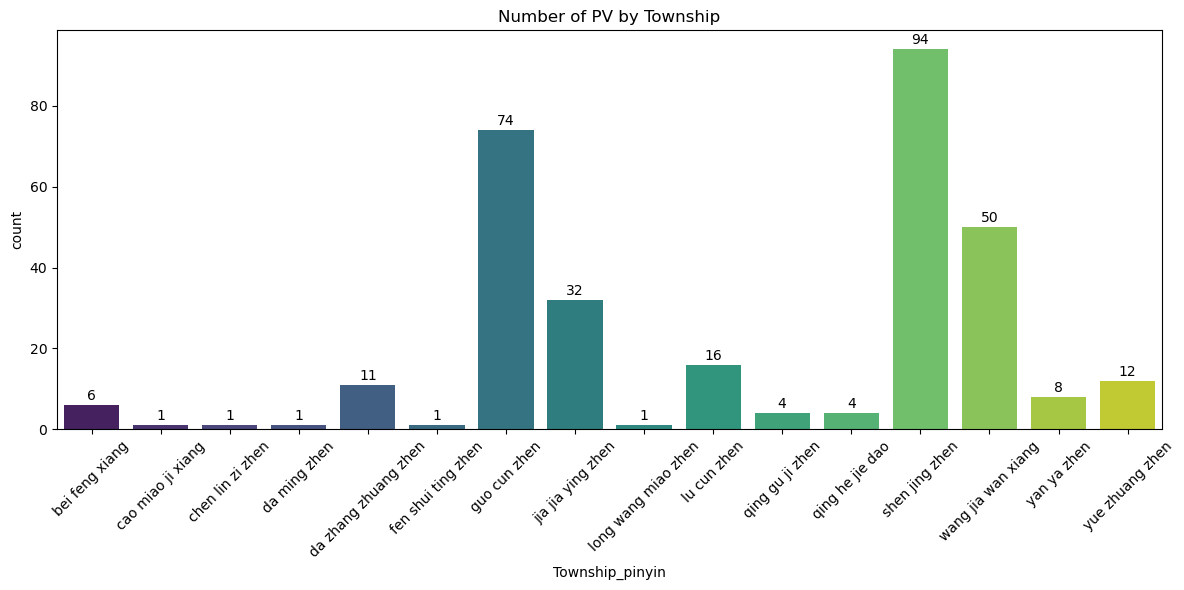

In [97]:
count_by_townships = joined.groupby('Township_pinyin').size().reset_index(name='count')

plt.figure(figsize=(12, 6))

# Create barplot with viridis palette
sns.barplot(
    data=count_by_townships, 
    x='Township_pinyin',
    y='count',
    hue='Township_pinyin',
    palette=sns.color_palette("viridis", n_colors=len(count_by_townships))
)

for index, row in count_by_townships.iterrows():
    plt.text(index, row['count'] + 0.5, row['count'], ha='center', va='bottom')

# Set title and show plot
plt.title('Number of PV by Township')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

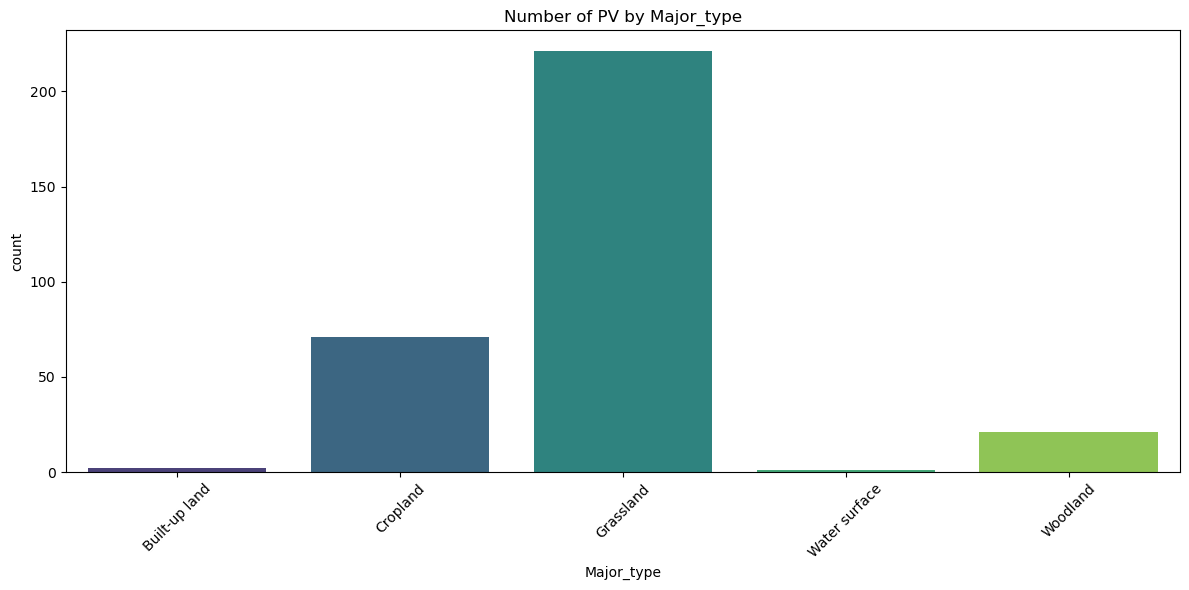

In [87]:
count_by_types = joined.groupby('Major_type').size().reset_index(name='count')

plt.figure(figsize=(12, 6))

# Create barplot with viridis palette
sns.barplot(
    data=count_by_types, 
    x='Major_type',
    y='count',
    hue='Major_type',
    palette=sns.color_palette("viridis", n_colors=len(count_by_types))
)

# Set title and show plot
plt.title('Number of PV by Major_type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Save

In [89]:
# Save as a new GeoJSON
output_folder = os.path.join("..", "..", "data", "data_processed")
os.makedirs(output_folder, exist_ok=True)


# Save GeoJSON files
joined.to_file(os.path.join(output_folder, "ChinaPV_2010_2022.geojson"), driver="GeoJSON")

### Before 2015

In [90]:
df_2010 = joined[joined['Inst_year'] == 2010]

df_2014 = joined[joined['Inst_year'] < 2015]

In [91]:
df_2010.info()
df_2014.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 3 entries, 2800 to 2871
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   PV_Area          3 non-null      float64 
 1   Inst_time        3 non-null      float64 
 2   Inst_year        3 non-null      int32   
 3   Major_type       3 non-null      object  
 4   Lat              3 non-null      float64 
 5   Lon              3 non-null      float64 
 6   geometry         3 non-null      geometry
 7   Province         3 non-null      object  
 8   Province_pinyin  3 non-null      object  
 9   Province code    3 non-null      int32   
 10  City             3 non-null      object  
 11  City_pinyin      3 non-null      object  
 12  City code        3 non-null      int32   
 13  County           3 non-null      object  
 14  County_pinyin    3 non-null      object  
 15  County code      3 non-null      int32   
 16  Township         3 non-null      object

In [92]:
# Save as a new GeoJSON
output_folder = os.path.join("..", "..", "data", "data_processed", "2010_2022", "before_2015")
os.makedirs(output_folder, exist_ok=True)


# Save GeoJSON files
df_2010.to_file(os.path.join(output_folder, "ChinaPV_2010.geojson"), driver="GeoJSON")
df_2014.to_file(os.path.join(output_folder, "ChinaPV_2014.geojson"), driver="GeoJSON")

### 2015 - 2018

In [93]:
df_2015 = joined[joined['Inst_year'] <= 2015]
df_2016 = joined[joined['Inst_year'] <= 2016]
df_2017 = joined[joined['Inst_year'] <= 2017]
df_2018 = joined[joined['Inst_year'] <= 2018]

In [94]:
# Save as a new GeoJSON
output_folder = os.path.join("..", "..", "data", "data_processed", "2010_2022", "2015_2018")
os.makedirs(output_folder, exist_ok=True)


# Save GeoJSON files
df_2015.to_file(os.path.join(output_folder, "ChinaPV_2015.geojson"), driver="GeoJSON")
df_2016.to_file(os.path.join(output_folder, "ChinaPV_2016.geojson"), driver="GeoJSON")
df_2017.to_file(os.path.join(output_folder, "ChinaPV_2017.geojson"), driver="GeoJSON")
df_2018.to_file(os.path.join(output_folder, "ChinaPV_2018.geojson"), driver="GeoJSON")

### After 2018

In [95]:
df_2019 = joined[joined['Inst_year'] <= 2019]
df_2022 = joined[joined['Inst_year'] <= 2022]

In [96]:
# Save as a new GeoJSON
output_folder = os.path.join("..", "..", "data", "data_processed", "2010_2022", "after_2018")
os.makedirs(output_folder, exist_ok=True)


# Save GeoJSON files
df_2019.to_file(os.path.join(output_folder, "ChinaPV_2019.geojson"), driver="GeoJSON")
df_2022.to_file(os.path.join(output_folder, "ChinaPV_2022.geojson"), driver="GeoJSON")